# 08 - Pipeline `clip-probe` (frozen CLIP embeddings + trained neural head)

Extract embeddings from a **frozen CLIP** image encoder, then train a small **MLP head** on them. CLIP features encode high-level semantic/distributional cues, so the head learns to flag *deviation from the real manifold* rather than generator-specific artifacts — the **best vehicle for cross-generator generalization**.

**Sections:** 0 Setup · 1 Frozen CLIP embeddings (cached) · 2 Head · 3 Train · 4 Curves · 5 In-distribution eval · 6 Cross-generator (OOD) preview · 7 Embedding t-SNE · 8 Save metrics.json.

Requires `03_split_and_preprocessing` (uses the 256px cache to embed quickly). Artifacts → `notebooks/artifacts/clip-probe/{models,figures,metrics}`.

## 0 - Setup

In [1]:
import sys, time
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython.display import display

_here = Path.cwd()
_nb_dir = _here if (_here / "utils").is_dir() else _here / "notebooks"
if str(_nb_dir) not in sys.path:
    sys.path.insert(0, str(_nb_dir))

from utils import datasets as D, models as M, training as T, metrics as Me, viz as V, embed
from utils.paths import repo_paths, artifact_dirs

torch.manual_seed(42); np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PATHS = repo_paths(_nb_dir)
DATA_DIR = PATHS["data"]; AIR_DIR = DATA_DIR / "ai-real-images"; TINY_DIR = DATA_DIR / "tiny-genimage"
SPLIT_PATH = AIR_DIR / "manifest_split.csv"
CACHE_DIR = AIR_DIR / "cache"

PIPELINE = "clip-probe"
ENCODER = "ViT-B-32/openai"      # frozen CLIP encoder (open_clip)
NORM = "clip"
NUM_WORKERS = 8
dirs = artifact_dirs(PIPELINE)
print("device:", device, "| pipeline:", PIPELINE, "| encoder:", ENCODER)

device: cuda | pipeline: clip-probe | encoder: ViT-B-32/openai


## 1 - Frozen CLIP embeddings (cached)

Embed every image with the frozen encoder **once** and cache to `.npy`. For `ai-real-images` we embed straight from the 256px cache (fast, no JPEG decode); for `tiny-genimage` (OOD) we decode the files. The first CLIP run downloads weights (~600 MB).

In [2]:
clip_model, clip_pre, clip_dev = embed.load_clip()   # ViT-B-32 / openai by default
ms = pd.read_csv(SPLIT_PATH); ms = ms[ms["keep"]]

emb, lab = {}, {}
for split in ["train", "val", "test"]:
    sub = ms[ms["split_final"] == split].sort_values("cache_idx")   # align with memmap row order
    lab[split] = (sub["label"].values == "fake").astype(np.float32)
    ep = AIR_DIR / f"clip_emb_{split}.npy"
    if ep.exists():
        emb[split] = np.load(ep)
    else:
        mm = np.load(CACHE_DIR / f"cache_{split}_256.npy", mmap_mode="r")
        t0 = time.time(); emb[split] = embed.embed_uint8(clip_model, clip_dev, mm); del mm
        np.save(ep, emb[split]); print(f"  embedded {split} in {time.time()-t0:.0f}s")
    print(f"{split}: {emb[split].shape}")
EMB_DIM = emb["train"].shape[1]

ood = pd.read_csv(TINY_DIR / "manifest_clean.csv")
ood = ood[ood["keep"]].reset_index(drop=True)
oep = TINY_DIR / "clip_emb.npy"
if oep.exists():
    emb_ood = np.load(oep)
else:
    t0 = time.time(); emb_ood = embed.embed_paths(ood["filepath"].tolist(), clip_model, clip_pre, clip_dev, batch_size=128)
    np.save(oep, emb_ood); print(f"  embedded OOD in {time.time()-t0:.0f}s")
lab_ood = (ood["label"].values == "fake").astype(np.float32)
print("ood:", emb_ood.shape, "| embedding dim:", EMB_DIM)

C:\Users\user\AppData\Roaming\Python\Python312\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(
c:\Users\user\Desktop\MSc - AI\Εξάμηνο 2ο\Βαθιά Μάθηση\deepfake-detection\notebooks\utils\embed.py:43: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_numpy.cpp:212.)
  x = torch.from_numpy(b).to(device).permute(0, 3, 1, 2).float() / 255.0


  embedded train in 77s
train: (43127, 512)
  embedded val in 8s
val: (4792, 512)
  embedded test in 20s
test: (11963, 512)
  embedded OOD in 245s
ood: (34998, 512) | embedding dim: 512


## 2 - Head

A small MLP (Linear → ReLU → Dropout → Linear) on the frozen embedding. We keep it neural (not sklearn) to stay within the deep-learning scope.

In [3]:
head = M.build_mlp_head(EMB_DIM, hidden=256, p_drop=0.3).to(device)
print("head params:", f"{M.count_params(head):,}")

def emb_loader(split_emb, split_lab, bs, shuffle):
    ds = torch.utils.data.TensorDataset(torch.from_numpy(split_emb), torch.from_numpy(split_lab))
    return torch.utils.data.DataLoader(ds, batch_size=bs, shuffle=shuffle)

train_loader = emb_loader(emb["train"], lab["train"], 512, True)
val_loader = emb_loader(emb["val"], lab["val"], 1024, False)
test_loader = emb_loader(emb["test"], lab["test"], 1024, False)

head params: 131,585


## 3 - Train the head

Fast (embeddings are tiny vectors). AdamW + cosine, many epochs, early-stop on val AUC.

In [4]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(head.parameters(), lr=1e-3, weight_decay=1e-4)
EPOCHS = 50; spe = len(train_loader)
scheduler = T.build_cosine_with_warmup(optimizer, total_steps=EPOCHS * spe, warmup_steps=2 * spe)
stopper = T.EarlyStopper(mode="max", patience=8, min_delta=1e-4)
history = {"train_loss": [], "val_loss": [], "val_auc": [], "val_acc": []}
best_auc = -1.0; ckpt_path = dirs["models"] / "best.pt"

for epoch in range(EPOCHS):
    tr_m = T.train_one_epoch(head, train_loader, optimizer, loss_fn, device, scheduler=scheduler, label_smooth=0.05)
    yv, pv, vloss = T.evaluate(head, val_loader, device, loss_fn)
    vm = Me.classification_metrics(yv, pv)
    history["train_loss"].append(tr_m["loss"]); history["val_loss"].append(vloss)
    history["val_auc"].append(vm["auc_roc"]); history["val_acc"].append(vm["accuracy"])
    improved, stop = stopper.step(vm["auc_roc"])
    if improved:
        best_auc = vm["auc_roc"]
        T.save_checkpoint(ckpt_path, head, optimizer, epoch=epoch, best_metric=best_auc, extra={"history": history})
    if (epoch + 1) % 5 == 0 or improved:
        print(f"epoch {epoch+1:02d} | train_loss {tr_m['loss']:.4f} | val_auc {vm['auc_roc']:.4f} | val_acc {vm['accuracy']:.4f}{'  *best' if improved else ''}")
    if stop:
        print("early stopping"); break

epoch 01 | train_loss 0.6546 | val_auc 0.9549 | val_acc 0.8802  *best
epoch 02 | train_loss 0.3733 | val_auc 0.9702 | val_acc 0.9076  *best
epoch 03 | train_loss 0.2782 | val_auc 0.9767 | val_acc 0.9178  *best
epoch 04 | train_loss 0.2628 | val_auc 0.9790 | val_acc 0.9257  *best
epoch 05 | train_loss 0.2540 | val_auc 0.9805 | val_acc 0.9276  *best
epoch 06 | train_loss 0.2488 | val_auc 0.9814 | val_acc 0.9268  *best
epoch 07 | train_loss 0.2446 | val_auc 0.9822 | val_acc 0.9295  *best
epoch 08 | train_loss 0.2418 | val_auc 0.9828 | val_acc 0.9301  *best
epoch 09 | train_loss 0.2390 | val_auc 0.9834 | val_acc 0.9322  *best
epoch 10 | train_loss 0.2368 | val_auc 0.9839 | val_acc 0.9328  *best
epoch 11 | train_loss 0.2345 | val_auc 0.9843 | val_acc 0.9338  *best
epoch 12 | train_loss 0.2322 | val_auc 0.9846 | val_acc 0.9366  *best
epoch 13 | train_loss 0.2307 | val_auc 0.9850 | val_acc 0.9386  *best
epoch 14 | train_loss 0.2291 | val_auc 0.9853 | val_acc 0.9397  *best
epoch 15 | train_los

## 4 - Training curves

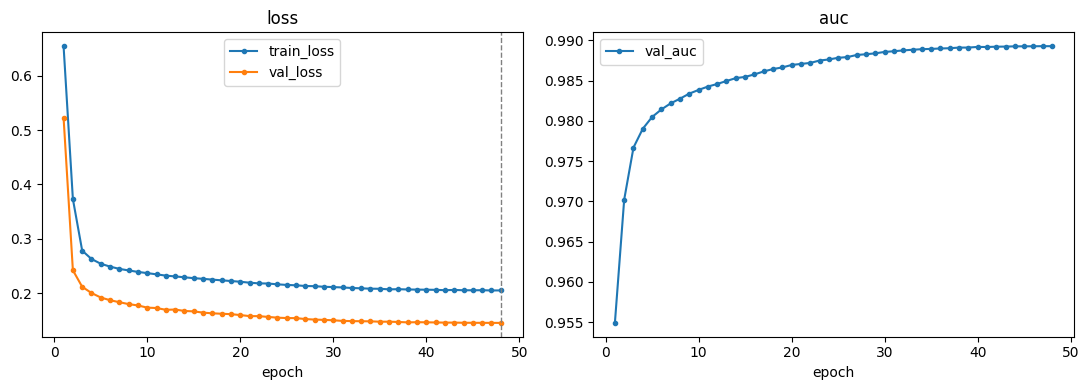

In [5]:
V.plot_training_curves(history).savefig(dirs["figures"] / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 5 - In-distribution evaluation (ai-real-images test)

tuned threshold (on val): 0.4922


,threshold,n,n_fake,n_real,accuracy,f1_macro,precision,recall,auc_roc,pr_auc,mcc,brier
0,0.5,11963,5977,5986,0.951183,0.95118,0.957732,0.943952,0.990285,0.990758,0.902458,0.037854


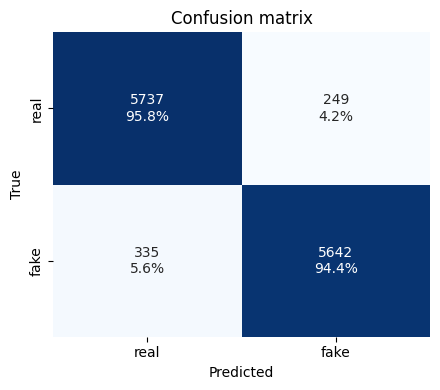

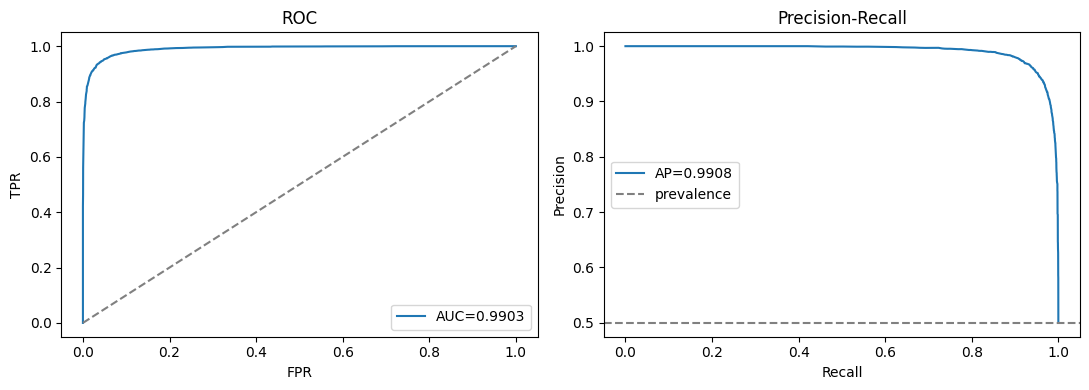

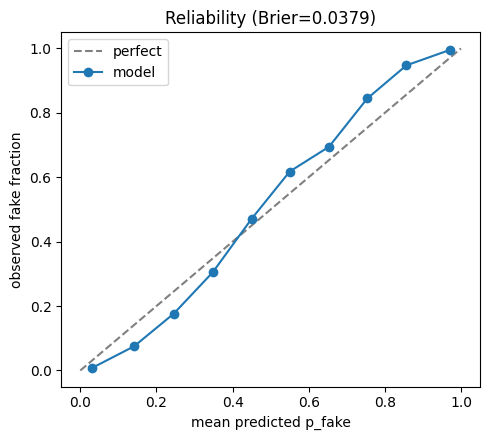

In [6]:
T.load_checkpoint(ckpt_path, head, map_location=device)
yt, pt, _ = T.evaluate(head, test_loader, device)
yv, pv, _ = T.evaluate(head, val_loader, device)
tuned = Me.best_f1_threshold(yv, pv)
m05 = Me.classification_metrics(yt, pt, threshold=0.5)
mtuned = Me.classification_metrics(yt, pt, threshold=tuned["threshold"])
print("tuned threshold (on val):", round(tuned["threshold"], 4))
display(Me.summary_table(m05))
V.plot_confusion(m05["confusion_matrix"]).savefig(dirs["figures"] / "confusion.png", dpi=150, bbox_inches="tight")
V.plot_roc_pr(yt, pt).savefig(dirs["figures"] / "roc_pr.png", dpi=150, bbox_inches="tight")
V.plot_reliability(yt, pt).savefig(dirs["figures"] / "reliability.png", dpi=150, bbox_inches="tight")
plt.show()

## 6 - Cross-generator (OOD) preview

**The key result for this pipeline** — CLIP features should generalize to unseen generators better than the CNNs.

,generator,accuracy,n
0,adm,0.650200,5000
1,biggan,0.473800,5000
2,glide,0.547600,5000
3,midjourney,0.689338,4999
4,sdv5,0.613523,4999
5,vqdm,0.428400,5000
6,wukong,0.638600,5000


overall OOD accuracy: 0.5773  (in-dist test acc: 0.9512)


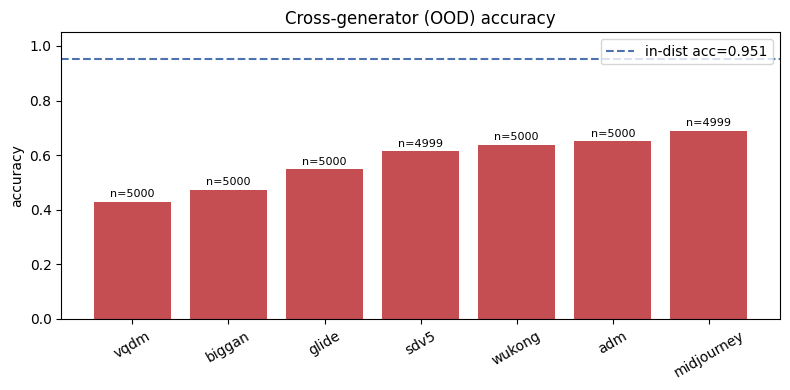

In [7]:
GEN_MAP = {
    "imagenet_ai_0419_biggan": "biggan", "imagenet_ai_0419_vqdm": "vqdm",
    "imagenet_ai_0424_sdv5": "sdv5", "imagenet_ai_0424_wukong": "wukong",
    "imagenet_ai_0508_adm": "adm", "imagenet_glide": "glide", "imagenet_midjourney": "midjourney",
}
ood_loader = emb_loader(emb_ood, lab_ood, 1024, False)
yo, po, _ = T.evaluate(head, ood_loader, device)
ood = ood.assign(p_fake=po, y_true=yo)
ood["y_pred"] = (ood["p_fake"] >= 0.5).astype(int)
ood["generator"] = ood["source"].map(GEN_MAP).fillna(ood["source"])
rows = [{"generator": gen, "accuracy": float((g["y_pred"] == g["y_true"]).mean()), "n": int(len(g))}
        for gen, g in ood.groupby("generator")]
per_gen = pd.DataFrame(rows)
overall_ood = float((ood["y_pred"] == ood["y_true"]).mean())
display(per_gen)
print(f"overall OOD accuracy: {overall_ood:.4f}  (in-dist test acc: {m05['accuracy']:.4f})")
V.plot_per_generator_bar(per_gen, ref_acc=m05["accuracy"]).savefig(dirs["figures"] / "ood_per_generator.png", dpi=150, bbox_inches="tight")
plt.show()

## 7 - Embedding t-SNE

Visualize the frozen CLIP space: in-distribution test by label, and OOD by generator. Real/fake separability and per-generator clustering explain the generalization behavior. (t-SNE/PCA for visualization only.)

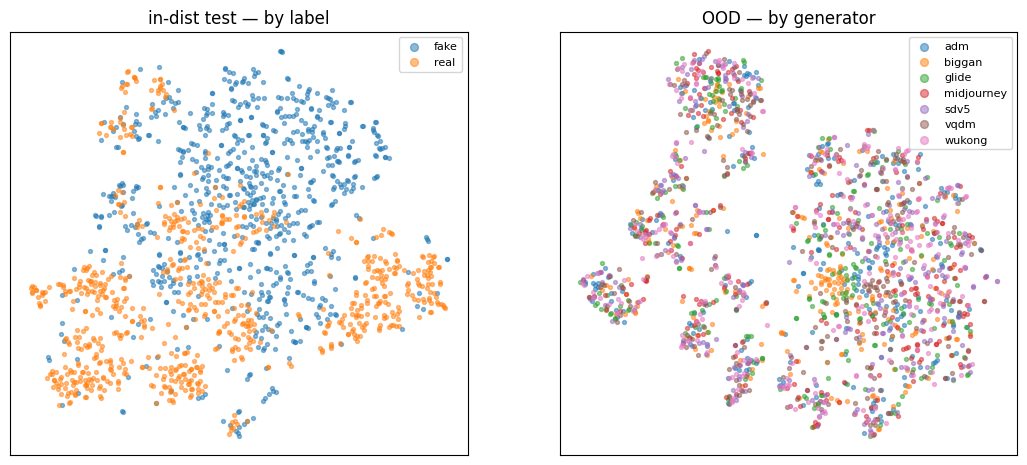

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def tsne2d(X, seed=42):
    Xs = StandardScaler().fit_transform(X)
    Xp = PCA(n_components=min(50, X.shape[1]), random_state=seed).fit_transform(Xs)
    return TSNE(n_components=2, init="pca", perplexity=30, random_state=seed).fit_transform(Xp)

def scatter(ax, xy, labels, title):
    labels = pd.Series(list(labels)).reset_index(drop=True)
    for v in sorted(labels.unique().tolist()):
        msk = (labels == v).to_numpy()
        ax.scatter(xy[msk, 0], xy[msk, 1], s=8, alpha=0.5, label=str(v))
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([]); ax.legend(markerscale=2, fontsize=8)

rng = np.random.RandomState(42)
ti = rng.choice(len(emb["test"]), size=min(1500, len(emb["test"])), replace=False)
oi = rng.choice(len(emb_ood), size=min(1800, len(emb_ood)), replace=False)
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
scatter(axes[0], tsne2d(emb["test"][ti]), np.where(lab["test"][ti] > 0.5, "fake", "real"), "in-dist test — by label")
scatter(axes[1], tsne2d(emb_ood[oi]), ood["generator"].values[oi], "OOD — by generator")
fig.savefig(dirs["figures"] / "tsne_embeddings.png", dpi=150, bbox_inches="tight")
plt.show()

## 8 - Save metrics.json

In [9]:
record = {
    "pipeline": PIPELINE,
    "created": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "encoder": ENCODER, "embedding_dim": int(EMB_DIM), "normalization": NORM,
    "dataset": {"in_distribution": "ai-real-images", "ood": "tiny-genimage"},
    "threshold_default": 0.5, "threshold_tuned": tuned["threshold"],
    "in_distribution": {"at_0.5": m05, "at_tuned": mtuned},
    "ood": {"overall_accuracy": overall_ood,
             "per_generator": {r.generator: {"accuracy": r.accuracy, "n": r.n} for r in per_gen.itertuples()},
             "preview": True},
    "train_history": {"epochs": len(history["val_auc"]), "best_epoch": int(np.argmax(history["val_auc"])) + 1, "best_val_auc": float(max(history["val_auc"]))},
    "figures": {"training_curves": "figures/training_curves.png", "confusion": "figures/confusion.png",
                 "roc_pr": "figures/roc_pr.png", "reliability": "figures/reliability.png",
                 "ood_per_generator": "figures/ood_per_generator.png", "tsne": "figures/tsne_embeddings.png"},
}
Me.save_metrics(record, dirs["metrics"] / "metrics.json")
print("saved", dirs["metrics"] / "metrics.json")
print("\nin-dist @0.5: acc {accuracy:.4f} f1 {f1_macro:.4f} auc {auc_roc:.4f} | OOD overall acc {ood:.4f}".format(ood=overall_ood, **m05))

saved C:\Users\user\Desktop\MSc - AI\Εξάμηνο 2ο\Βαθιά Μάθηση\deepfake-detection\notebooks\artifacts\clip-probe\metrics\metrics.json

in-dist @0.5: acc 0.9512 f1 0.9512 auc 0.9903 | OOD overall acc 0.5773


**Next:** `09_two-stream.ipynb` (RGB + frequency fusion).